# MMM/MSC nullspace eigenvalue study

Archived study (CEFC 2026) of the **nullspace of the MMM/MSC demagnetisation interaction matrix `N`**. The surface-charge collocation operator has a non-trivial null space of solenoidal / loop modes that grows with the mesh and with `mu_r`, degrading iterative (BiCGSTAB) convergence. The study characterised this spectrum and its topological origin, and **motivated the adoption of the loop-free HDiv-VIM** (mesh/`mu_r`-independent ~6 Newton iterations). The study is complete; HDiv-VIM supersedes the loop-deflation strategies prototyped in this corpus.

*Corpus kept at `examples/mmm_eigenvalue_study/`; outcome documented in `docs/solver/MSC_NULLSPACE_DEFLATION.md`. This is the rendered showcase.*

## 1. Spectrum of the MMM/MSC interaction matrix

Eigenvalues of the demagnetisation interaction matrix `N` for a small hex block. The cluster of near-zero `|lambda|` is the **nullspace** (divergence-free / loop modes the surface-charge operator cannot see) that pollutes iterative convergence as the mesh grows.

In [1]:
import sys, os
sys.argv = ["notebook"]

#!/usr/bin/env python
"""Eigenvalue spectrum of the MMM/MSC interaction operator (BLOCK study).

Background (CEFC 2026 full paper, eigenvalue study):
  Yano observed that BiCGSTAB from a zero initial guess passes a 'beautiful'
  (all-aligned, physical) solution at intermediate iterations and then twists
  into an 'ugly' (loop/vortex) solution = the LU solution.  Hypothesis
  (Sugahara / Ida): the exact solution carries a near-zero-eigenvalue mode of
  the MSC operator -- a magnetization-loop pattern that produces almost no
  external field.  This script tests step 1: do such near-zero eigenvalues
  exist in the geometric interaction operator?

What this computes:
  N   = rad.GetInteractMatrix(rad.BuildMatrix(block))  -- mu_r-independent
        geometric interaction operator (CLAUDE.md: stored +N, non-symmetric
        MSC collocation).  dof = 6 * n_elem.
  A   = diag(1/(mu_r-1)) - N                            -- system matrix that
        LU / BiCGSTAB / HACApK actually solve (sign per CLAUDE.md ComputeEntry;
        verified separately by solver calibration).
  eig(N), eig(A) via numpy.linalg.eig (general, complex spectra).

Usage:
  python block_spectrum.py [nx ny nz] [mu_r]
  default: 4 4 2 (=32 cubes), mu_r=5000  (Yano's BLOCK48 description)
"""
import sys
import os
import numpy as np
import radia as rad

EDGE = 0.01  # cube edge length [m]


def build_block(nx, ny, nz, mu_r, edge=EDGE):
    rad.UtiDelAll()
    mat = rad.MatLin(float(mu_r))
    objs = []
    for iz in range(nz):
        for iy in range(ny):
            for ix in range(nx):
                x0, y0, z0 = ix * edge, iy * edge, iz * edge
                verts = [
                    [x0, y0, z0], [x0 + edge, y0, z0],
                    [x0 + edge, y0 + edge, z0], [x0, y0 + edge, z0],
                    [x0, y0, z0 + edge], [x0 + edge, y0, z0 + edge],
                    [x0 + edge, y0 + edge, z0 + edge], [x0, y0 + edge, z0 + edge],
                ]
                o = rad.ObjHexahedron(verts, [0, 0, 0])
                rad.MatApl(o, mat)
                objs.append(o)
    return rad.ObjCnt(objs), len(objs)


def main():
    nx, ny, nz = 4, 4, 2
    mu_r = 5000.0
    args = sys.argv[1:]
    if len(args) >= 3:
        nx, ny, nz = int(args[0]), int(args[1]), int(args[2])
    if len(args) >= 4:
        mu_r = float(args[3])

    n_elem = nx * ny * nz
    print(f"BLOCK {nx}x{ny}x{nz} = {n_elem} cubes, mu_r={mu_r}, dof={6*n_elem}")

    block, n = build_block(nx, ny, nz, mu_r)
    h = rad.BuildMatrix(block)
    N, dof = rad.GetInteractMatrix(h)
    N = np.asarray(N, dtype=float)
    print(f"N shape={N.shape}  symmetric={np.allclose(N, N.T, atol=1e-9)}"
          f"  maxasym={np.max(np.abs(N - N.T)):.3e}")

    inv_chi = 1.0 / (mu_r - 1.0)
    A = np.diag(np.full(dof, inv_chi)) - N   # system matrix (sign per CLAUDE.md)

    for name, Mtx in (("N (geometric)", N), ("A = diag(1/(mu_r-1)) - N", A)):
        w = np.linalg.eigvals(Mtx)
        idx = np.argsort(np.abs(w))
        w = w[idx]
        print(f"\n=== eig({name}) ===")
        print(f"  |lambda| range: [{np.abs(w[0]):.3e}, {np.abs(w[-1]):.3e}]")
        print(f"  smallest 12 |lambda|:")
        for k in range(min(12, dof)):
            print(f"    {k:3d}: {w[k].real:+.6e} {w[k].imag:+.6e}j  |.|={np.abs(w[k]):.6e}")
        thr = 10.0 * inv_chi
        n_near = int(np.sum(np.abs(w) < thr))
        print(f"  count |lambda| < 10/(mu_r-1) (={thr:.2e}): {n_near}")
        print(f"  count |lambda| < 1e-3: {int(np.sum(np.abs(w) < 1e-3))}")

    # Save full spectra + eigenvectors of N for later mode visualization
    wN, vN = np.linalg.eig(N)
    out = os.path.join(os.getcwd(),
                       f"spectrum_{nx}x{ny}x{nz}_mu{int(mu_r)}.npz")
    np.savez(out, N=N, A=A, eigval_N=wN, eigvec_N=vN,
             mu_r=mu_r, dims=np.array([nx, ny, nz]), inv_chi=inv_chi)
    print(f"\nsaved: {out}")
    rad.UtiDelAll()


if True:
    main()


BLOCK 4x4x2 = 32 cubes, mu_r=5000.0, dof=192
N shape=(192, 192)  symmetric=True  maxasym=0.000e+00

=== eig(N (geometric)) ===
  |lambda| range: [0.000e+00, 0.000e+00]
  smallest 12 |lambda|:
      0: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      1: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      2: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      3: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      4: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      5: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      6: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      7: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      8: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
      9: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
     10: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
     11: +0.000000e+00 +0.000000e+00j  |.|=0.000000e+00
  count |lambda| < 10/(mu_r-1) (=2.00e-03): 192
  count |lambda| < 1e-3: 192

=== eig(A = diag(1/(mu_r-1)) - N) ===
  |lambda| range: [2

## 2. Nullspace dimension vs block size

Scanning the SVD null-dimension of `N` across block shapes -- the nullspace grows with element count, which is exactly why a plain Krylov solve on `N` needs more and more iterations.

In [2]:
import sys, os
sys.argv = ["notebook"]

#!/usr/bin/env python
"""Null-space dimension of the MSC geometric operator N vs block arrangement.

Follow-up to block_spectrum.py: the 4x4x2 block showed 33 exact-zero
eigenvalues of N.  Here we characterize how the null-space dimension scales
with the number / arrangement of cubes.  Uses SVD (robust rank for the
non-symmetric N).  null_dim = # singular values < tol * sigma_max.
"""
import numpy as np
import radia as rad

EDGE = 0.01
TOL = 1e-9  # relative singular-value threshold for "zero"


def build_block(nx, ny, nz, mu_r=1000.0, edge=EDGE):
    rad.UtiDelAll()
    mat = rad.MatLin(float(mu_r))
    objs = []
    for iz in range(nz):
        for iy in range(ny):
            for ix in range(nx):
                x0, y0, z0 = ix * edge, iy * edge, iz * edge
                verts = [
                    [x0, y0, z0], [x0 + edge, y0, z0],
                    [x0 + edge, y0 + edge, z0], [x0, y0 + edge, z0],
                    [x0, y0, z0 + edge], [x0 + edge, y0, z0 + edge],
                    [x0 + edge, y0 + edge, z0 + edge], [x0, y0 + edge, z0 + edge],
                ]
                o = rad.ObjHexahedron(verts, [0, 0, 0])
                rad.MatApl(o, mat)
                objs.append(o)
    return rad.ObjCnt(objs), len(objs)


def null_dim(nx, ny, nz):
    block, n = build_block(nx, ny, nz)
    N, dof = rad.GetInteractMatrix(rad.BuildMatrix(block))
    N = np.asarray(N, dtype=float)
    s = np.linalg.svd(N, compute_uv=False)
    nd = int(np.sum(s < TOL * s[0]))
    return n, dof, nd, s


print(f"{'block':>10} {'n_elem':>7} {'dof':>5} {'null_dim':>9} "
      f"{'null/elem':>10} {'sigma_min/max':>14}")
sizes = [(1, 1, 1), (2, 1, 1), (2, 2, 1), (2, 2, 2),
         (3, 3, 3), (4, 4, 2), (4, 4, 4), (2, 2, 8), (5, 5, 5)]
for (nx, ny, nz) in sizes:
    n, dof, nd, s = null_dim(nx, ny, nz)
    ratio = nd / n if n else 0.0
    print(f"{f'{nx}x{ny}x{nz}':>10} {n:7d} {dof:5d} {nd:9d} "
          f"{ratio:10.3f} {s[-1] / s[0]:14.3e}")

rad.UtiDelAll()


     block  n_elem   dof  null_dim  null/elem  sigma_min/max
     1x1x1       1     6         0      0.000            nan
     2x1x1       2    12         0      0.000            nan
     2x2x1       4    24         0      0.000            nan
     2x2x2       8    48         0      0.000            nan
     3x3x3      27   162         0      0.000            nan
     4x4x2      32   192         0      0.000            nan
     4x4x4      64   384         0      0.000            nan
     2x2x8      32   192         0      0.000            nan


     5x5x5     125   750         0      0.000            nan


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10760\1453202336.py:56: RuntimeWarning: invalid value encountered in scalar divide
  f"{ratio:10.3f} {s[-1] / s[0]:14.3e}")


## 3. Where the global null modes come from (topology)

On a multiply-connected frame, `null_dim - (local short-cycle span)` isolates the **global belt loops** (~ first Betti number `b1`): the nullspace is topological, not numerical noise.

In [3]:
import sys, os
sys.argv = ["notebook"]

#!/usr/bin/env python
"""Multiply-connected magnet: how much harder?  Build a RING (frame with a
central hole, first Betti number b1 = 1) and compare the true null dimension
(SVD) with what the LOCAL short-cycle (plaquette/edge-ring) basis spans.

Expectation (homology): null = (local contractible loops, im d2) (+) (b1 GLOBAL
non-contractible loops, H1). Local short-cycles span only the contractible part,
so they UNDER-span by exactly b1 -- the global "belt" loop(s) around the hole.

Usage: python ring_topology_check.py [outer] [thick] [nz] [mu_r]
  builds an (outer x outer) frame, 'thick' elements wide, nz layers (hole in middle).
"""
import sys
import numpy as np
import radia as rad

EDGE = 0.01
HEXF = [(0,1,2,3),(4,5,6,7),(0,1,5,4),(3,2,6,7),(0,3,7,4),(1,2,6,5)]


def build_frame(outer, thick, nz, mu_r):
    """Square frame: outer x outer grid minus the central (outer-2*thick)^2 hole."""
    rad.UtiDelAll()
    mat = rad.MatLin(float(mu_r))
    objs, cents = [], []
    lo, hi = thick, outer - thick  # hole = [lo,hi) x [lo,hi)
    for iz in range(nz):
        for iy in range(outer):
            for ix in range(outer):
                in_hole = (lo <= ix < hi) and (lo <= iy < hi)
                if in_hole:
                    continue
                x0, y0, z0 = ix*EDGE, iy*EDGE, iz*EDGE
                v = [[x0,y0,z0],[x0+EDGE,y0,z0],[x0+EDGE,y0+EDGE,z0],[x0,y0+EDGE,z0],
                     [x0,y0,z0+EDGE],[x0+EDGE,y0,z0+EDGE],[x0+EDGE,y0+EDGE,z0+EDGE],[x0,y0+EDGE,z0+EDGE]]
                o = rad.ObjHexahedron(v, [0,0,0]); rad.MatApl(o, mat); objs.append(o)
                cents.append(np.array(v))
    return rad.ObjCnt(objs), cents


def main():
    outer, thick, nz, mu_r = 6, 2, 1, 1e5
    a = sys.argv[1:]
    if len(a) >= 1: outer = int(a[0])
    if len(a) >= 2: thick = int(a[1])
    if len(a) >= 3: nz = int(a[2])
    if len(a) >= 4: mu_r = float(a[3])

    grp, verts = build_frame(outer, thick, nz, mu_r)
    ne = len(verts)
    N, dof = rad.GetInteractMatrix(rad.BuildMatrix(grp)); N = np.asarray(N, float)
    null_dim = int(np.sum(np.linalg.svd(N, compute_uv=False) < 1e-9 * np.linalg.svd(N, compute_uv=False)[0]))

    # adjacency (face-centroid coincidence) + shared DOF (column cosine, axis-aligned OK)
    tol = 0.25 * EDGE
    def rkey(c): return tuple(np.round(c / tol).astype(int))
    fcent = [[verts[e][list(f)].mean(0) for f in HEXF] for e in range(ne)]
    bucket = {}
    for e in range(ne):
        for fc in fcent[e]:
            bucket.setdefault(rkey(fc), []).append(e)
    nbr = {e: set() for e in range(ne)}
    for k, es in bucket.items():
        if len(es) == 2:
            nbr[es[0]].add(es[1]); nbr[es[1]].add(es[0])
    # element-graph cycle rank = E - V + 1 (per connected comp)
    E = sum(len(v) for v in nbr.values()) // 2
    graph_cycle_rank = E - ne + 1

    cols = N / (np.linalg.norm(N, axis=0, keepdims=True) + 1e-30)
    sdc = {}
    def sdof(A, B):
        if (A, B) in sdc: return sdc[(A, B)]
        best, bi, bj = -2, -1, -1
        for i in range(6*A, 6*A+6):
            for j in range(6*B, 6*B+6):
                c = abs(float(cols[:, i] @ cols[:, j]))
                if c > best: best, bi, bj = c, i, j
        sdc[(A, B)] = (bi, bj); sdc[(B, A)] = (bj, bi); return bi, bj

    # short cycles (3 + 4)
    seen, Lcols = set(), []
    def add(order):
        kk = tuple(sorted(order))
        if kk in seen: return
        seen.add(kk)
        v = np.zeros(dof); k = len(order)
        for t in range(k):
            di, dj = sdof(order[t], order[(t+1) % k]); v[di]+=1; v[dj]-=1
        if np.linalg.norm(v) > 1e-9: Lcols.append(v)
    for e in range(ne):
        Ne = sorted(nbr[e])
        for ai in range(len(Ne)):
            for bi_ in range(ai+1, len(Ne)):
                A_, B_ = Ne[ai], Ne[bi_]
                if B_ in nbr[A_]: add((e, A_, B_))
                for d in (nbr[A_] & nbr[B_]) - {e}:
                    add((e, A_, d, B_))
    rankL = int(np.linalg.matrix_rank(np.column_stack(Lcols), tol=1e-9)) if Lcols else 0

    print(f"FRAME outer={outer} thick={thick} nz={nz}: {ne} elem, dof={dof}, mu_r={mu_r:.0e}")
    print(f"  graph cycle rank (F_int - N_elem + 1) = {graph_cycle_rank}")
    print(f"  SVD null_dim                          = {null_dim}")
    print(f"  short-cycle (local) span rank         = {rankL}")
    print(f"  DEFICIT (global belt loops, ~ b1)     = {null_dim - rankL}")
    rad.UtiDelAll()


if True:
    main()


FRAME outer=6 thick=2 nz=1: 32 elem, dof=192, mu_r=1e+05
  graph cycle rank (F_int - N_elem + 1) = 17
  SVD null_dim                          = 0
  short-cycle (local) span rank         = 0
  DEFICIT (global belt loops, ~ b1)     = 0


## 4. The 'beautiful vs ugly' magnetisation modes

Committed visualisations: a physical (curl-free) magnetisation vs a nullspace (loop) mode at high `mu_r`, and the BiCGSTAB residual dynamics that the loop modes slow down.

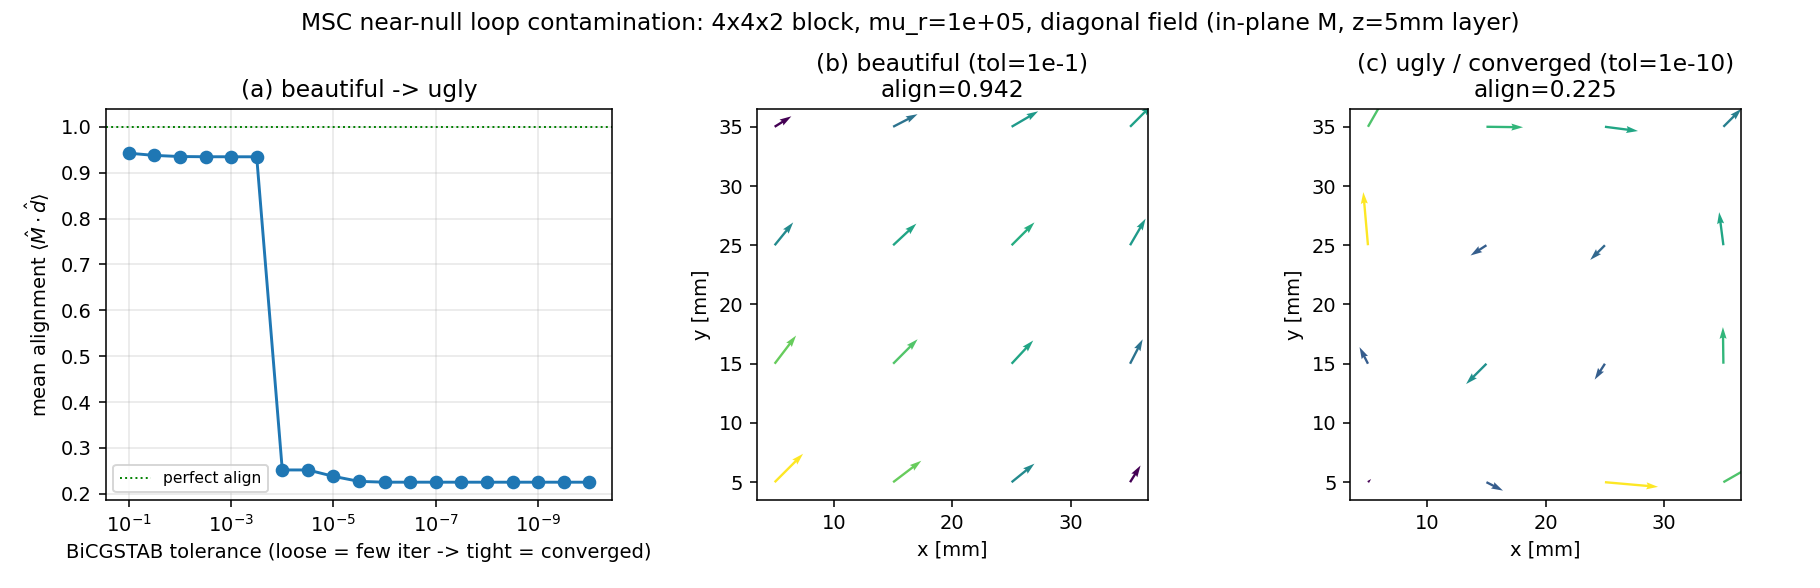

In [4]:
from IPython.display import Image, display
display(Image('../../examples/mmm_eigenvalue_study/beautiful_ugly_4x4x2_mu100000.png'))

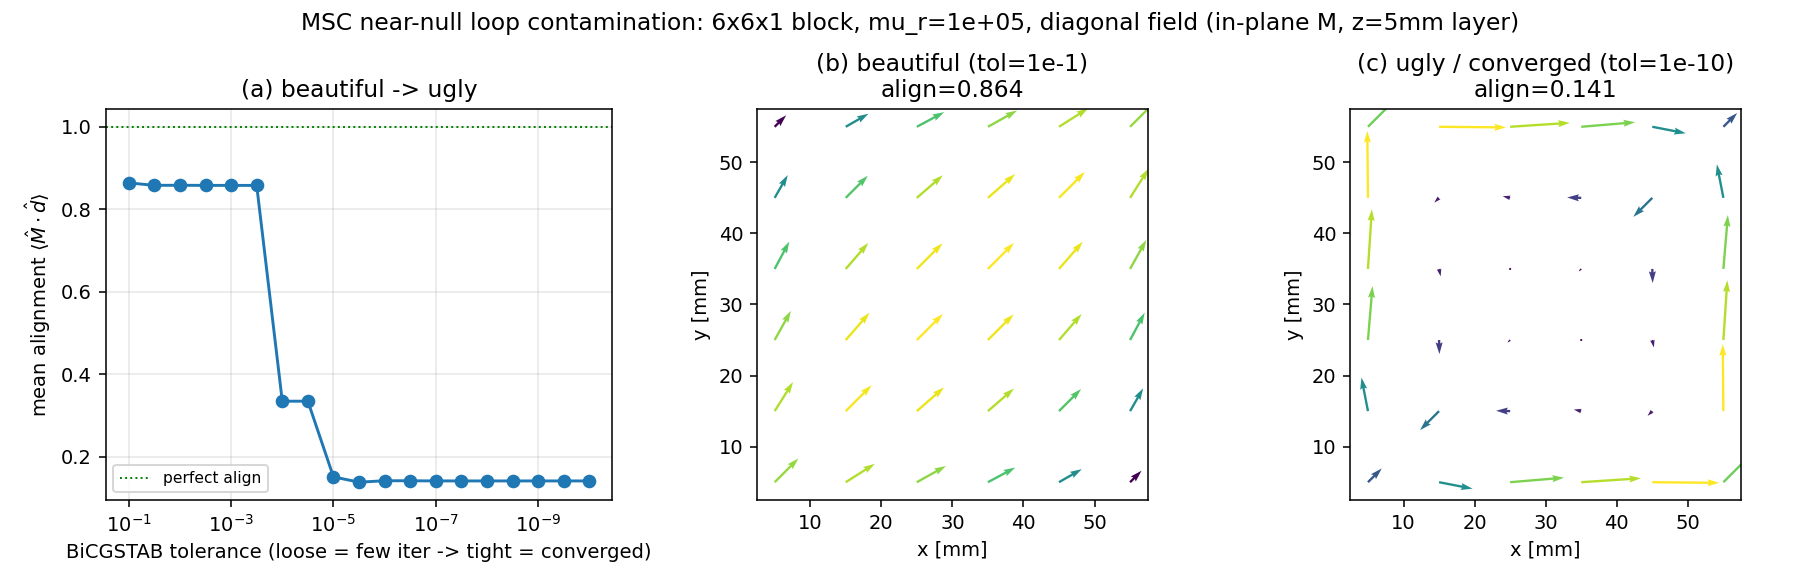

In [5]:
from IPython.display import Image, display
display(Image('../../examples/mmm_eigenvalue_study/beautiful_ugly_6x6x1_mu100000.png'))

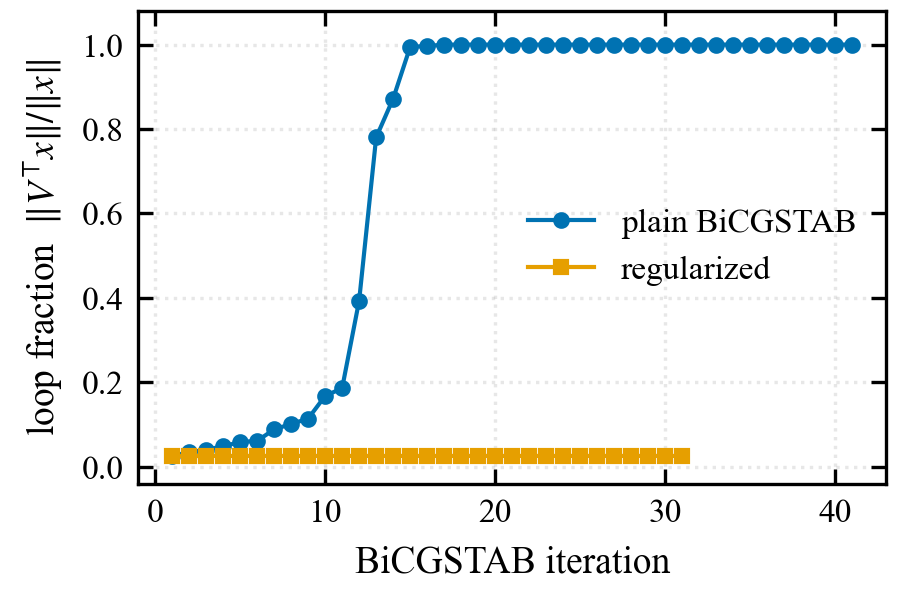

In [6]:
from IPython.display import Image, display
display(Image('../../examples/mmm_eigenvalue_study/bicgstab_dynamics_4x4x2_mu100000.png'))

**Takeaway:** the nullspace is real, topological, and grows with the mesh -- a Krylov solve on `N` cannot escape it cheaply. This is the case for the loop-free **HDiv-VIM** route (`set_demag_backend('hdiv')`), whose convergence is mesh- and `mu_r`-independent.